In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 19 — From geometry to cautious interaction hypotheses

Read `lessons/19_lesson.md` and `workbooks/19_workbook.md` first. Predict each result before executing. All outputs here are reference examples, not a grade.

**Evidence boundary:** real static stereo observations are bundled; analytical controls are labeled synthetic. No VGGT checkpoint is run by this notebook.

Source keys: U01, S01

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json, time
import numpy as np
import matplotlib.pyplot as plt
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/shape_lab").is_dir())
if str(ROOT / "src") not in sys.path: sys.path.insert(0, str(ROOT / "src"))
from shape_lab.stereo import reference_sample, point_cloud, depth_from_disparity
from shape_lab.geometry import *
from shape_lab.display import save_json, show_and_save, plot_diagram
left, right, reference_disparity, calibration = reference_sample()
OUT = ROOT / "reports" / "stage_19"
OUT.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(20260920)
print("Real data:", left.shape, right.shape, reference_disparity.shape)
print("Data source:", calibration["source"])

Real data: (500, 741, 3) (500, 741, 3) (500, 741)
Data source: scikit-image 0.26.0 stereo_motorcycle; Middlebury 2014


## 1. Real geometry supports distance, not contact labels
Select two reference-derived scene points and compute a distance. The calculation is real-data-based, but neither point is labeled as a hand or ball. A threshold on it cannot manufacture a contact annotation.

In [3]:
from shape_lab.temporal import causal_separation_events,match_events
cloud,rc=point_cloud(reference_disparity,calibration,stride=20)
a,b=100,101;distance=float(np.linalg.norm(cloud[a]-cloud[b]))
print("Two static source pixels:",rc[a],rc[b],"reference-derived separation (m):",distance)
print("Contact label:","unavailable")
R = exp_so3([.2,-.1,.05])
common_frame = cloud[[a,b]]@R.T + np.array([1.,2.,3.])
assert np.isclose(np.linalg.norm(common_frame[0]-common_frame[1]),distance)
assert np.isclose(np.linalg.norm(2*cloud[a]-2*cloud[b]),2*distance)
print("Common rigid frame change preserves distance; a numerical scale change rescales it.")

Two static source pixels: [60 40] [60 60] reference-derived separation (m): 0.16824126124172512
Contact label: unavailable
Common rigid frame change preserves distance; a numerical scale change rescales it.


## 2. A causal event state machine — generated controls
A candidate requires prior visible near observations and subsequent visible far observations. Missing data resets evidence. A minimum duration is expressed here as a sample count plus a maximum permitted gap; this is not frame-rate-independent duration logic. Contact remains uncertified.

Generated-control candidate: [{'label': 'separation_candidate', 'onset_s': 0.24, 'decision_s': 0.26, 'contact_certified': False, 'evidence': 'observed_distance_thresholds'}]


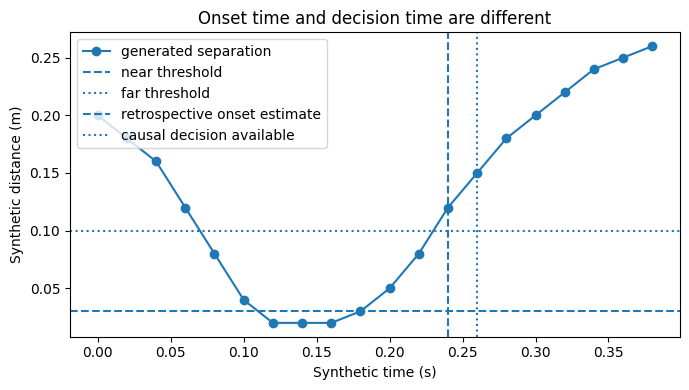

In [4]:
times=np.arange(20)*.02
dist=np.array([.20,.18,.16,.12,.08,.04,.02,.02,.02,.03,.05,.08,.12,.15,.18,.20,.22,.24,.25,.26])
visible=np.ones(len(times),bool)
events=causal_separation_events(times,dist,visible,near=.03,far=.1,min_near=3,min_far=2,max_gap_s=.05)
assert len(events)==1 and not events[0]["contact_certified"]
print("Generated-control candidate:",events)
# Prefix causality: future samples cannot alter an already emitted decision.
for end in range(1,len(times)+1):
    prefix=causal_separation_events(times[:end],dist[:end],visible[:end],near=.03,far=.1,min_near=3,min_far=2,max_gap_s=.05)
    expected=[e for e in events if e["decision_s"]<=times[end-1]+1e-12]
    assert prefix==expected
occluded=visible.copy();occluded[11:13]=False
hidden_events=causal_separation_events(times,dist,occluded,near=.03,far=.1,min_near=3,min_far=2,max_gap_s=.05)
assert hidden_events==[]
# Never near: a hard negative for the prerequisite, not proof against all false events.
never_near=causal_separation_events(times,np.full(len(times),.2),visible)
assert never_near==[]
plt.figure(figsize=(7,4));plt.plot(times,dist,marker="o",label="generated separation")
plt.axhline(.03,linestyle="--",label="near threshold");plt.axhline(.1,linestyle=":",label="far threshold")
plt.axvline(events[0]["onset_s"],linestyle="--",label="retrospective onset estimate");plt.axvline(events[0]["decision_s"],linestyle=":",label="causal decision available")
plt.xlabel("Synthetic time (s)");plt.ylabel("Synthetic distance (m)");plt.title("Onset time and decision time are different");plt.legend()
show_and_save(OUT / "causal_candidate.png")

## 3. One-to-one event matching
The target annotation is constructed for this control. Matching within a declared tolerance illustrates the metric mechanics. It does not estimate real basketball-event performance.

In [5]:
target=[.24]
match=match_events([e["onset_s"] for e in events],target,tolerance_s=.025)
print("Generated-control event matching:",match)
assert match["true_positive"]==1
save_json(OUT / "results.json",{"real_static_pair_distance_m":distance,"real_source_pixels":[rc[a],rc[b]],"real_contact_ground_truth":None,"control_source":"explicit synthetic distance/time sequence, not observed basketball", "events":events,"prefix_causality_checked":True,"occlusion_reset_checked":True,"never_near_negative_checked":True,"synthetic_matching":match,"real_event_precision":None,"real_event_recall":None,"contact_certified":False})

Generated-control event matching: {'true_positive': 1, 'false_positive': 0, 'false_negative': 0, 'precision': 1.0, 'recall': 1.0, 'matched_signed_onset_errors_s': [0.0]}


## Explain before continuing
A hand can pass near a ball without touching it: would this rule rule that out? Why is a label such as `separation_candidate` more honest than `verified_release`? What changes when identities swap? Explain how offline smoothing that uses future frames would change the evaluation contract.